# Supervised Learning - Random Forest

<h5 style="font-size:14px;">

<b>Definition:</b> Random Forest is an ensemble supervised learning algorithm that combines multiple decision trees to improve classification performance and reduce overfitting. The final prediction is obtained by aggregating the predictions of individual trees, usually through majority voting.

<b>Working Principle:</b><br>
Random Forest builds a large number of decision trees using randomly selected subsets of the training data and randomly selected features.

Each tree is trained independently, and the final output is determined by combining the predictions of all trees.

<b>Theoretical Concepts:</b><br>
- <b>Ensemble Learning</b> – technique that combines multiple models to obtain better performance.<br>
- <b>Bootstrap Sampling</b> – random sampling with replacement used to create training subsets.<br>
- <b>Majority Voting</b> – final class is chosen based on the most frequent prediction.

<b>Advantages:</b><br>
- Higher accuracy compared to a single decision tree.<br>
- Reduces overfitting.<br>
- Robust to noise in data.<br>

<b>Limitations:</b><br>
- More computationally expensive.<br>
- Less interpretable than a single decision tree.<br>
- Model size can be large.

<b>Main Parameters Used:</b><br>
- Number of trees in the forest (n_estimators).<br>
- Maximum depth of trees.<br>
- Number of features considered for splitting.
</h5>

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

## Dataset Description – Breast Cancer Dataset

The dataset used in this project comes from the Kaggle platform and contains information about patients diagnosed with breast cancer. The objective is to classify the patient’s status based on clinical and tumor-related characteristics.

### Demographic and Clinical Features

- **Age** – the age of the patient.
- **Race** – the patient's race (e.g., White, Other).
- **Marital Status** – the patient's marital status (e.g., Married, Single).
- **T Stage** – classification of the primary tumor according to its size and extent.
- **N Stage** – indicates whether lymph nodes are affected.
- **6th Stage** – the clinical stage of the cancer according to medical classification.
- **Differentiate** – the degree of cellular differentiation, which shows how much the tumor cells resemble normal cells.

- **Grade** – the histological grade of the tumor, indicating the aggressiveness of the cancer:
  - Grade 1 – less aggressive tumor
  - Grade 2 – moderately aggressive tumor
  - Grade 3 – highly aggressive tumor

- **A Stage** – shows the extent of the neoplasm:
  - Regional – local spread
  - Distant – metastasis to distant organs

- **Tumor Size** – the size of the tumor measured in millimeters.
- **Estrogen Status** – indicates the presence or absence of estrogen receptors.
- **Progesterone Status** – indicates the status of progesterone receptors.
- **Regional Node Examined** – the number of lymph nodes examined.
- **Regional Node Positive** – the number of lymph nodes with confirmed metastasis.

### Target Variable

- **Status** – the variable to be classified:
  - Alive
  - Dead

In [105]:
data = pd.read_csv("../data/Breast_Cancer.csv")

In [106]:
data.head(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
5,51,White,Single,T1,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,18,2,89,Alive
6,51,White,Married,T1,N1,IIA,Well differentiated,1,Regional,8,Positive,Positive,11,1,54,Alive
7,40,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,9,1,14,Dead
8,40,White,Divorced,T4,N3,IIIC,Poorly differentiated,3,Regional,103,Positive,Positive,20,18,70,Alive
9,69,White,Married,T4,N3,IIIC,Well differentiated,1,Distant,32,Positive,Positive,21,12,92,Alive


In [107]:
data.tail(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4014,40,White,Married,T3,N1,IIIA,Moderately differentiated,2,Regional,68,Positive,Positive,22,2,86,Alive
4015,65,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,40,Positive,Positive,4,4,68,Alive
4016,54,White,Married,T2,N1,IIB,Well differentiated,1,Regional,50,Positive,Positive,29,2,52,Alive
4017,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,28,Negative,Negative,2,1,19,Dead
4018,64,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,10,Positive,Positive,11,1,70,Alive
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive
4023,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,7,2,100,Alive


In [108]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

In [109]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [110]:
data.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')

In [111]:
data.shape

(4024, 16)

In [112]:
data.dtypes

Age                       int64
Race                        str
Marital Status              str
T Stage                     str
N Stage                     str
6th Stage                   str
differentiate               str
Grade                       str
A Stage                     str
Tumor Size                int64
Estrogen Status             str
Progesterone Status         str
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                      str
dtype: object

In [113]:
data.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [114]:
data.duplicated().sum()

np.int64(1)

In [115]:
data.nunique()

Age                        40
Race                        3
Marital Status              5
T Stage                     4
N Stage                     3
6th Stage                   5
differentiate               4
Grade                       4
A Stage                     2
Tumor Size                110
Estrogen Status             2
Progesterone Status         2
Regional Node Examined     54
Reginol Node Positive      38
Survival Months           107
Status                      2
dtype: int64

<Axes: >

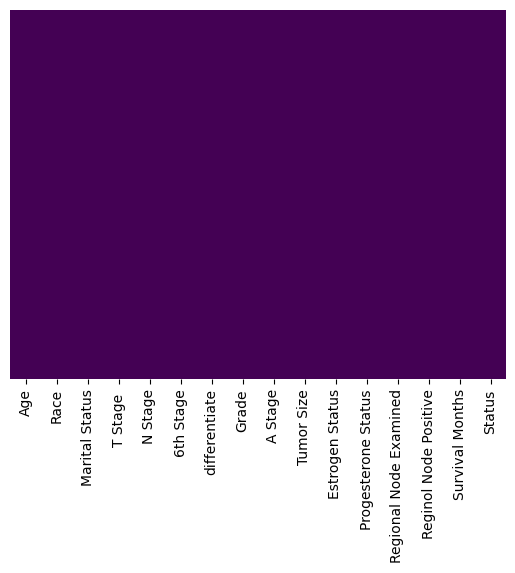

In [116]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [117]:
categorical_cols = [
    'Race', 'Marital Status', 'T Stage ', 'N Stage',
    '6th Stage', 'differentiate', 'Grade', 'A Stage',
    'Estrogen Status', 'Progesterone Status', 'Status'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

In [118]:
data.head(5)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0


In [119]:
print(data.columns.tolist())

['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


In [120]:
X = data.drop("Status", axis = 1)
y = data["Status"]

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [123]:
y_pred = model.predict(X_test)

In [124]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9142857142857143


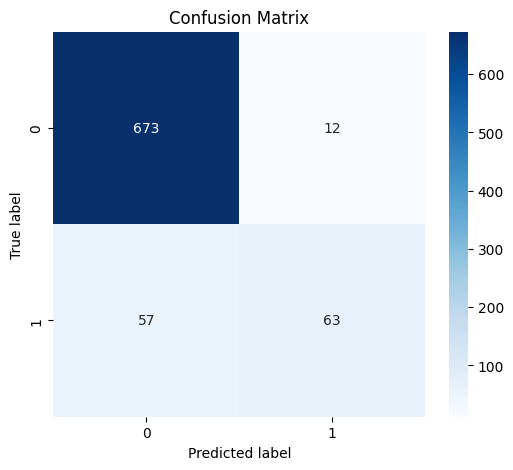

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [126]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       685
           1       0.84      0.53      0.65       120

    accuracy                           0.91       805
   macro avg       0.88      0.75      0.80       805
weighted avg       0.91      0.91      0.91       805



In [127]:
new_patient = [
    45,   # Age
    0,    # Race (ex: White → 0 după LabelEncoder)
    1,    # Marital Status (ex: Married → 1)
    2,    # T Stage
    1,    # N Stage
    2,    # 6th Stage
    1,    # differentiate
    2,    # Grade
    0,    # A Stage (Regional → 0)
    35,   # Tumor Size (mm)
    1,    # Estrogen Status (Positive → 1)
    1,    # Progesterone Status (Positive → 1)
    5,    # Regional Node Examined
    2,    # Reginol Node Positive
    60    # Survival Months
]

In [131]:
new_patient_df = pd.DataFrame([new_patient], columns=X.columns)

prediction = model.predict(new_patient_df)
probability = model.predict_proba(new_patient_df)

if prediction[0] == 1:
    print("\nResult: MALIGNANT tumor")
else:
    print("\nResult: BENIGN tumor")

print("Probabilities:", probability)


Result: BENIGN tumor
Probabilities: [[0.88 0.12]]
